In [1]:
from typing import TypedDict, Dict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    name: str
    message: str

In [5]:
class AgentState(TypedDict):
    name: str
    message: str

def greeting_node(state: AgentState) -> AgentState:
    '''Simple node that adds a greeting message to the state'''
    state['message'] = "Hey " + state['name'] + ", how are you?"
    return state

In [8]:
from langgraph.graph import StateGraph
graph = StateGraph(AgentState)
graph.add_node("greeting", greeting_node)
graph.set_entry_point("greeting")
graph.set_finish_point("greeting")

app = graph.compile()

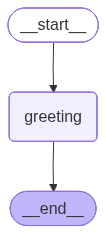

{'name': 'Alice', 'message': 'Hey Alice, how are you?'}


In [10]:
from IPython.display import Image, display
display(Image(data=app.get_graph().draw_mermaid_png()))
result = app.invoke({'name': 'Alice'})
print(result)